# Pre-Gate Diagnostic: Calidad de Datos, IOL & Actividad del Motor Corto

Notebook de diagnóstico para responder:
- **(C) Calidad de datos OHLCV**: cobertura US (XNYS) y AR/CEDEAR (XBUE) sobre universo desde policy + snapshots.
- **(IOL) Calidad de ingesta**: auditoría de `fetch_log` (éxito, fallback, skip reasons, símbolos problemáticos).
- **(A) Actividad del motor**: señales y ventanas del pre-gate walk-forward.

Ejecutar todas las celdas. La sección **Diagnóstico automático** consolida flags de datos, IOL y motor.

In [14]:
import sqlite3
import json
import sys
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# ── Rutas ───────────────────────────────────────────────────
if (Path.cwd() / "config" / "policy.v1.yaml").exists():
    REPO_ROOT = Path.cwd()
elif (Path.cwd().parent / "config" / "policy.v1.yaml").exists():
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data.storage import MarketDB
from data.universe_selector import (
    dynamic_tops_from_db,
    load_merval_and_cedear_candidates,
    merge_fetch_universe,
    open_ar_position_symbols_from_db,
    static_ar_symbols_from_policy,
)

DB_PATH = REPO_ROOT / "data" / "market.db"
POLICY_PATH = REPO_ROOT / "config" / "policy.v1.yaml"
PRE_GATE_JSON = REPO_ROOT / "outputs" / "pre_gate_windows_180d_rsi.json"

LOOKBACK_DAYS = 180
END_DATE = date.today()
START_DATE = END_DATE - timedelta(days=LOOKBACK_DAYS)

VENUE_US = "XNYS"
VENUE_AR = "XBUE"
AR_VENUE_TAGS = ("AR", "XBUE")


def load_us_symbols_from_policy(policy: dict, repo_root: Path) -> list[str]:
    sym_cfg = policy.get("symbols", {}) or {}
    us_file = sym_cfg.get("whitelist_us_file")
    out: list[str] = []
    if us_file:
        with (repo_root / us_file).open(encoding="utf-8") as f:
            data = yaml.safe_load(f) or {}
        for key in ("etfs", "stocks", "adrs"):
            out.extend(data.get(key, []) or [])
    return sorted({str(s).strip().upper() for s in out if str(s).strip()})


def resolve_ar_universe_for_diagnostic(policy: dict, repo_root: Path, db: MarketDB) -> tuple[list[str], dict]:
    holdings = open_ar_position_symbols_from_db(db)
    ucfg = (policy.get("symbols", {}) or {}).get("universe_selection") or {}
    meta: dict = {"holdings_overlay": holdings}

    if ucfg.get("enabled"):
        merval, cedear, sel_date = dynamic_tops_from_db(db)
        if merval or cedear:
            symbols = merge_fetch_universe(merval, cedear, holdings)
            meta.update(
                {
                    "mode": "dynamic_snapshot",
                    "selection_date": sel_date.isoformat() if sel_date else None,
                    "merval_top": merval,
                    "cedear_top": cedear,
                }
            )
            return symbols, meta
        base = static_ar_symbols_from_policy(repo_root, policy)
        symbols = merge_fetch_universe(base, [], holdings)
        meta.update({"mode": "fallback_static_no_snapshot"})
        return symbols, meta

    base = static_ar_symbols_from_policy(repo_root, policy)
    symbols = merge_fetch_universe(base, [], holdings)
    meta["mode"] = "static_whitelist"
    return symbols, meta


policy = yaml.safe_load(POLICY_PATH.read_text(encoding="utf-8"))
db = MarketDB(str(DB_PATH))

US_SYMBOLS = load_us_symbols_from_policy(policy, REPO_ROOT)
AR_UNIVERSE_SYMBOLS, UNIVERSE_META = resolve_ar_universe_for_diagnostic(policy, REPO_ROOT, db)
MERVAL_CANDIDATES, CEDEAR_CANDIDATES = load_merval_and_cedear_candidates(REPO_ROOT, policy)

AR_MERVAL_SYMBOLS = [s for s in AR_UNIVERSE_SYMBOLS if s in set(MERVAL_CANDIDATES)]
AR_CEDEAR_SYMBOLS = [s for s in AR_UNIVERSE_SYMBOLS if s in set(CEDEAR_CANDIDATES)]
AR_OTHER_SYMBOLS = [
    s for s in AR_UNIVERSE_SYMBOLS if s not in set(AR_MERVAL_SYMBOLS) and s not in set(AR_CEDEAR_SYMBOLS)
]

DIAGNOSTIC_SYMBOLS = sorted(set(US_SYMBOLS) | set(AR_UNIVERSE_SYMBOLS))

print(f"Rango: {START_DATE} → {END_DATE}")
print(f"DB: {DB_PATH} (existe: {DB_PATH.exists()})")
print(f"Pre-gate JSON: {PRE_GATE_JSON} (existe: {PRE_GATE_JSON.exists()})")
print(f"US (XNYS): {len(US_SYMBOLS)} símbolos")
print(f"AR universo efectivo (XBUE): {len(AR_UNIVERSE_SYMBOLS)} — modo={UNIVERSE_META.get('mode')}")
print(f"  Merval en universo: {len(AR_MERVAL_SYMBOLS)} | CEDEAR: {len(AR_CEDEAR_SYMBOLS)} | overlay/otros: {len(AR_OTHER_SYMBOLS)}")
if UNIVERSE_META.get("selection_date"):
    print(f"  Snapshot dinámico: {UNIVERSE_META['selection_date']}")

Rango: 2025-11-20 → 2026-05-19
DB: c:\Users\Dell\Agus\Bot de Trading\data\market.db (existe: True)
Pre-gate JSON: c:\Users\Dell\Agus\Bot de Trading\outputs\pre_gate_windows_180d_rsi.json (existe: True)
US (XNYS): 15 símbolos
AR universo efectivo (XBUE): 10 — modo=static_whitelist
  Merval en universo: 10 | CEDEAR: 0 | overlay/otros: 0


In [15]:
# ── Carga OHLCV, calendarios y fetch_log ─────────────────────
conn = sqlite3.connect(str(DB_PATH))
conn.row_factory = sqlite3.Row

df_ohlcv = pd.read_sql_query(
    """
    SELECT symbol, ts, open, high, low, close, volume, venue
    FROM ohlcv
    WHERE ts BETWEEN ? AND ?
    ORDER BY ts, symbol
    """,
    conn,
    params=(START_DATE.isoformat(), END_DATE.isoformat()),
)
df_ohlcv["ts"] = pd.to_datetime(df_ohlcv["ts"])

df_cal_us = pd.read_sql_query(
    """
    SELECT ts FROM calendars
    WHERE venue = ? AND ts BETWEEN ? AND ?
    ORDER BY ts
    """,
    conn,
    params=(VENUE_US, START_DATE.isoformat(), END_DATE.isoformat()),
)
df_cal_ar = pd.read_sql_query(
    """
    SELECT ts FROM calendars
    WHERE venue = ? AND ts BETWEEN ? AND ?
    ORDER BY ts
    """,
    conn,
    params=(VENUE_AR, START_DATE.isoformat(), END_DATE.isoformat()),
)

try:
    df_fetch_log = pd.read_sql_query(
        """
        SELECT id, created_at, symbol, venue, status, source, skip_reason, extra
        FROM fetch_log
        WHERE date(created_at) >= date(?)
        ORDER BY created_at DESC
        """,
        conn,
        params=(START_DATE.isoformat(),),
    )
except Exception:
    df_fetch_log = pd.DataFrame(
        columns=["id", "created_at", "symbol", "venue", "status", "source", "skip_reason", "extra"]
    )

conn.close()

expected_sessions_us = set(pd.to_datetime(df_cal_us["ts"]).dt.date) if not df_cal_us.empty else set()
expected_sessions_ar = set(pd.to_datetime(df_cal_ar["ts"]).dt.date) if not df_cal_ar.empty else set()

df_us = df_ohlcv[df_ohlcv["symbol"].isin(US_SYMBOLS) & (df_ohlcv["venue"] == VENUE_US)].copy()
df_ar = df_ohlcv[
    df_ohlcv["symbol"].isin(AR_UNIVERSE_SYMBOLS) & df_ohlcv["venue"].isin(AR_VENUE_TAGS)
].copy()

print(f"Barras OHLCV totales: {len(df_ohlcv):,}")
print(f"  US filtradas: {len(df_us):,} | AR filtradas: {len(df_ar):,}")
print(f"Sesiones esperadas XNYS: {len(expected_sessions_us)} | XBUE: {len(expected_sessions_ar)}")
print(f"Filas fetch_log en ventana: {len(df_fetch_log):,}")
if df_ohlcv.empty:
    print("⚠ Sin OHLCV en el rango — ejecutar fetch_daily antes de diagnosticar.")
if df_fetch_log.empty:
    print("⚠ fetch_log vacío — correr scripts/fetch_daily.py tras ADR-049 para auditoría IOL.")

Barras OHLCV totales: 4,187
  US filtradas: 1,830 | AR filtradas: 1,180
Sesiones esperadas XNYS: 123 | XBUE: 120
Filas fetch_log en ventana: 66


---
## IOL — Calidad de datos de ingesta (`fetch_log`)

Métricas desde la trazabilidad persistida por `fetch_daily` / `fetch_and_store` (**ADR-049**):
éxito, fallback (total o parcial), `skip_reason` y símbolos con fallos recurrentes.

In [16]:
# Ajuste de cobertura US: incluir histórico venue='US' además de XNYS.
US_VENUE_TAGS = ("XNYS", "US")
df_us = df_ohlcv[
    df_ohlcv["symbol"].isin(US_SYMBOLS) & df_ohlcv["venue"].isin(US_VENUE_TAGS)
].copy()

venue_mix = (
    df_ohlcv[df_ohlcv["symbol"].isin(US_SYMBOLS)]
    .groupby("venue", dropna=False)
    .size()
    .sort_values(ascending=False)
)
print(f"[Ajuste] US filtradas ({US_VENUE_TAGS}): {len(df_us):,}")
if not venue_mix.empty:
    print("[Ajuste] Venue US observados:")
    print(venue_mix.to_string())
if "US" in set(venue_mix.index):
    print("⚠ Se detectó histórico venue='US' (pre ADR-037).")
    print("   La cobertura US ahora se calcula con ('XNYS','US').")

[Ajuste] US filtradas (('XNYS', 'US')): 3,007
[Ajuste] Venue US observados:
venue
XNYS    1830
US      1177
AR       236
⚠ Se detectó histórico venue='US' (pre ADR-037).
   La cobertura US ahora se calcula con ('XNYS','US').


════════════════════════════════════════════════════════════
  RESUMEN fetch_log
════════════════════════════════════════════════════════════
  Eventos: 66
  Tasa éxito (status=ok): 98.5%
  Tasa fallback (parcial o total): 15.2%
════════════════════════════════════════════════════════════

Por venue:
       events  ok  fallback   ok_rate  fallback_rate
venue                                               
XBUE       21  20        10  0.952381        0.47619
XNYS       45  45         0  1.000000        0.00000

Skip reasons:
skip_reason
(none)                  55
fallback_used           10
max_retries_exceeded     1

Effective source:
effective_source
yfinance    45
byma        20
iol          1

Símbolos con más fallos/skip:
symbol
GGAL    1


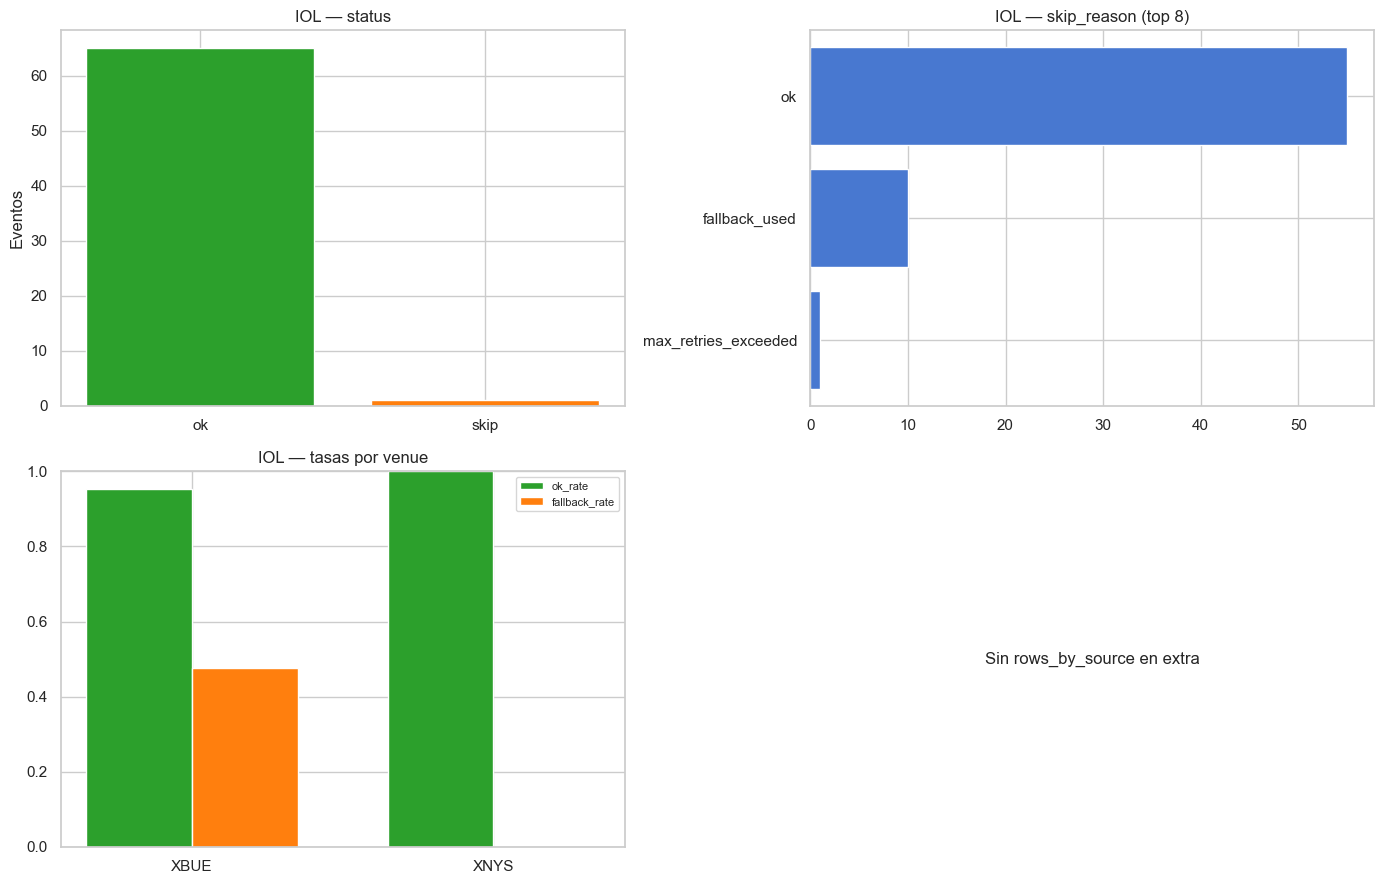

In [17]:
def _parse_fetch_extra(series: pd.Series) -> pd.DataFrame:
    rows = []
    for raw in series.fillna(""):
        try:
            rows.append(json.loads(raw) if raw else {})
        except json.JSONDecodeError:
            rows.append({})
    return pd.json_normalize(rows) if rows else pd.DataFrame()

if df_fetch_log.empty:
    print("Sin eventos en fetch_log para el lookback — omitir gráficos IOL.")
else:
    df_fl = df_fetch_log.copy()
    df_fl["created_at"] = pd.to_datetime(df_fl["created_at"], utc=True, errors="coerce")
    extra = _parse_fetch_extra(df_fl["extra"])
    if not extra.empty:
        df_fl = pd.concat([df_fl.reset_index(drop=True), extra], axis=1)

    df_fl["is_ok"] = df_fl["status"] == "ok"
    df_fl["is_fallback"] = (
        df_fl.get("partial_fallback", False).astype(bool)
        | (df_fl["skip_reason"] == "fallback_used")
        | (df_fl["source"] == "mixed")
    )

    n = len(df_fl)
    n_ok = int(df_fl["is_ok"].sum())
    n_fb = int(df_fl["is_fallback"].sum())
    print("═" * 60)
    print("  RESUMEN fetch_log")
    print("═" * 60)
    print(f"  Eventos: {n:,}")
    print(f"  Tasa éxito (status=ok): {n_ok / n:.1%}")
    print(f"  Tasa fallback (parcial o total): {n_fb / n:.1%}")
    print("═" * 60)

    by_venue = (
        df_fl.groupby("venue", dropna=False)
        .agg(events=("id", "count"), ok=("is_ok", "sum"), fallback=("is_fallback", "sum"))
        .assign(ok_rate=lambda d: d["ok"] / d["events"], fallback_rate=lambda d: d["fallback"] / d["events"])
    )
    print("\nPor venue:")
    print(by_venue.to_string())

    print("\nSkip reasons:")
    print(df_fl["skip_reason"].fillna("(none)").value_counts().to_string())

    print("\nEffective source:")
    src_col = "effective_source" if "effective_source" in df_fl.columns else "source"
    print(df_fl[src_col].fillna("(none)").value_counts().to_string())

    bad = (
        df_fl[~df_fl["is_ok"]]
        .groupby("symbol")
        .size()
        .sort_values(ascending=False)
        .head(15)
    )
    if not bad.empty:
        print("\nSímbolos con más fallos/skip:")
        print(bad.to_string())

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0, 0]
    status_counts = df_fl["status"].value_counts()
    ax.bar(status_counts.index.astype(str), status_counts.values, color=["#2ca02c", "#ff7f0e", "#d62728"][: len(status_counts)])
    ax.set_title("IOL — status")
    ax.set_ylabel("Eventos")

    ax = axes[0, 1]
    if "skip_reason" in df_fl.columns:
        sr = df_fl["skip_reason"].fillna("ok").value_counts().head(8)
        ax.barh(sr.index.astype(str), sr.values)
        ax.set_title("IOL — skip_reason (top 8)")
    ax.invert_yaxis()

    ax = axes[1, 0]
    if not by_venue.empty:
        x = np.arange(len(by_venue))
        w = 0.35
        ax.bar(x - w / 2, by_venue["ok_rate"], w, label="ok_rate", color="#2ca02c")
        ax.bar(x + w / 2, by_venue["fallback_rate"], w, label="fallback_rate", color="#ff7f0e")
        ax.set_xticks(x)
        ax.set_xticklabels(by_venue.index.astype(str))
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.set_title("IOL — tasas por venue")

    ax = axes[1, 1]
    rbs_totals = None
    if "rows_by_source" in df_fl.columns:
        rbs = df_fl["rows_by_source"].dropna()
        if len(rbs) and isinstance(rbs.iloc[0], dict):
            rbs_totals = pd.json_normalize(rbs).sum(numeric_only=True)
    if rbs_totals is None:
        src_cols = [c for c in ("iol", "byma", "yfinance") if c in df_fl.columns]
        if src_cols:
            rbs_totals = df_fl[src_cols].fillna(0).sum()
    if rbs_totals is not None and len(rbs_totals):
        ax.bar(rbs_totals.index.astype(str), rbs_totals.values)
        ax.set_title("IOL — barras atribuidas por proveedor")
    else:
        ax.text(0.5, 0.5, "Sin rows_by_source en extra", ha="center", va="center")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

---
## C — Calidad de Datos OHLCV
### C1. Cobertura por mercado (US / AR-CEDEAR)

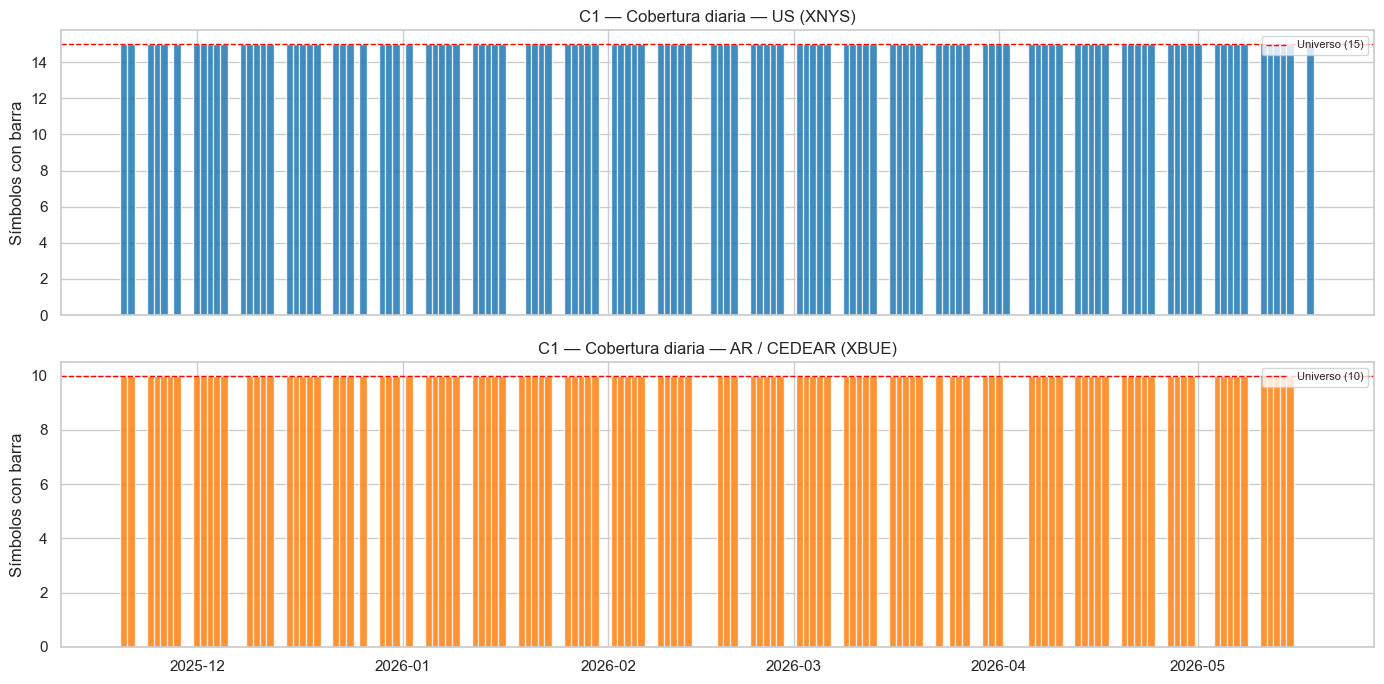

US: días con <50% cobertura: 0 (mín diario: 15)
AR: días con <50% cobertura: 0 (mín diario: 10)


In [18]:
def _coverage_daily(df: pd.DataFrame, universe: list[str]) -> pd.DataFrame:
    sub = df[df["symbol"].isin(universe)]
    out = (
        sub.groupby(sub["ts"].dt.date)["symbol"]
        .nunique()
        .rename("n_symbols")
        .reset_index()
    )
    out["ts"] = pd.to_datetime(out["ts"])
    return out

coverage_daily_us = _coverage_daily(df_us, US_SYMBOLS)
coverage_daily_ar = _coverage_daily(df_ar, AR_UNIVERSE_SYMBOLS)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, cov, n_expected, title, color in [
    (axes[0], coverage_daily_us, len(US_SYMBOLS), "US (XNYS)", "#1f77b4"),
    (axes[1], coverage_daily_ar, len(AR_UNIVERSE_SYMBOLS), "AR / CEDEAR (XBUE)", "#ff7f0e"),
]:
    if cov.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
        continue
    ax.bar(cov["ts"], cov["n_symbols"], width=1.2, alpha=0.85, color=color)
    ax.axhline(n_expected, color="red", ls="--", lw=1, label=f"Universo ({n_expected})")
    ax.set_ylabel("Símbolos con barra")
    ax.set_title(f"C1 — Cobertura diaria — {title}")
    ax.legend(loc="upper right", fontsize=8)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()

for label, cov, n_exp in [
    ("US", coverage_daily_us, len(US_SYMBOLS)),
    ("AR", coverage_daily_ar, len(AR_UNIVERSE_SYMBOLS)),
]:
    if cov.empty:
        print(f"{label}: sin cobertura en DB")
        continue
    low = cov[cov["n_symbols"] < n_exp * 0.5]
    print(f"{label}: días con <50% cobertura: {len(low)} (mín diario: {cov['n_symbols'].min()})")

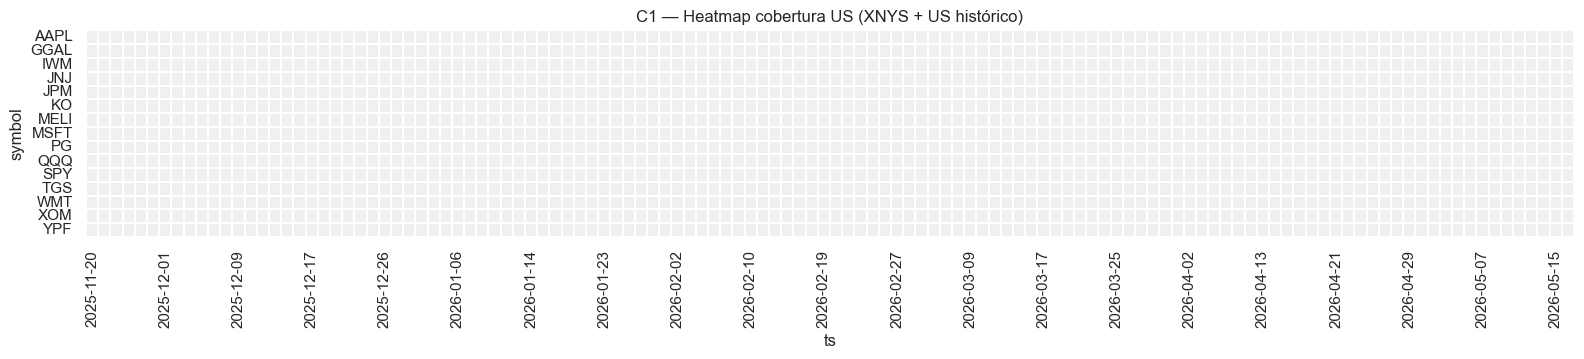

symbol
AAPL    100.0%
GGAL    100.0%
IWM     100.0%
JNJ     100.0%
JPM     100.0%
KO      100.0%
MELI    100.0%
MSFT    100.0%
PG      100.0%
QQQ     100.0%
SPY     100.0%
TGS     100.0%
WMT     100.0%
XOM     100.0%
YPF     100.0%


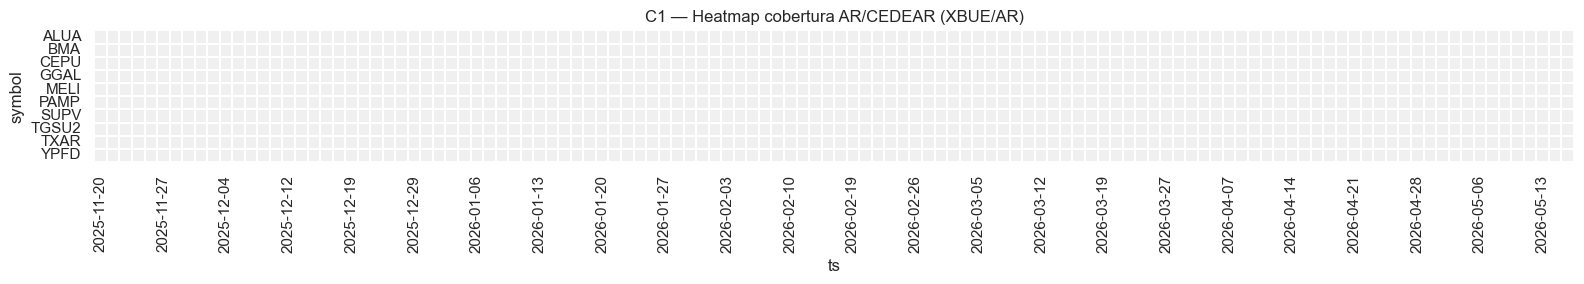

symbol
ALUA     100.0%
BMA      100.0%
CEPU     100.0%
GGAL     100.0%
MELI     100.0%
PAMP     100.0%
SUPV     100.0%
TGSU2    100.0%
TXAR     100.0%
YPFD     100.0%


In [19]:
coverage_pct_us = None
coverage_pct_ar = None


def _coverage_pivot(df: pd.DataFrame, symbols: list[str], title: str):
    if not symbols:
        print(f"{title}: universo vacío")
        return None
    sub = df[df["symbol"].isin(symbols)].copy()
    pivot = (
        sub.assign(present=1)
        .pivot_table(index="symbol", columns=sub["ts"].dt.date, values="present", fill_value=0)
    )
    for sym in symbols:
        if sym not in pivot.index:
            pivot.loc[sym] = 0
    pivot = pivot.loc[symbols]
    fig, ax = plt.subplots(figsize=(16, max(3, len(symbols) * 0.25)))
    sns.heatmap(
        pivot,
        cmap=["#f0f0f0", "#2ca02c"],
        cbar=False,
        linewidths=0.3,
        xticklabels=max(1, len(pivot.columns) // 20),
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    pct = pivot.mean(axis=1).sort_values()
    print(pct.apply(lambda x: f"{x:.1%}").to_string())
    return pct

coverage_pct_us = _coverage_pivot(
    df_us, US_SYMBOLS, "C1 — Heatmap cobertura US (XNYS + US histórico)"
)
coverage_pct_ar = _coverage_pivot(
    df_ar, AR_UNIVERSE_SYMBOLS, "C1 — Heatmap cobertura AR/CEDEAR (XBUE/AR)"
)

### C3. Continuidad temporal: ¿hay gaps entre sesiones?

In [20]:
# Días con datos vs calendarios
actual_dates_us = set(df_us["ts"].dt.date) if not df_us.empty else set()
actual_dates_ar = set(df_ar["ts"].dt.date) if not df_ar.empty else set()

missing_us = sorted(expected_sessions_us - actual_dates_us)
missing_ar = sorted(expected_sessions_ar - actual_dates_ar)

print(f"XNYS esperadas: {len(expected_sessions_us)} | días con barra US: {len(actual_dates_us)} | faltantes: {len(missing_us)}")
if missing_us[:10]:
    print(f"  US → {missing_us[:10]}{'...' if len(missing_us) > 10 else ''}")
print(f"XBUE esperadas: {len(expected_sessions_ar)} | días con barra AR: {len(actual_dates_ar)} | faltantes: {len(missing_ar)}")
if missing_ar[:10]:
    print(f"  AR → {missing_ar[:10]}{'...' if len(missing_ar) > 10 else ''}")

XNYS esperadas: 123 | días con barra US: 122 | faltantes: 1
  US → [datetime.date(2026, 5, 19)]
XBUE esperadas: 120 | días con barra AR: 118 | faltantes: 2
  AR → [datetime.date(2026, 5, 18), datetime.date(2026, 5, 19)]


In [21]:
def _gap_table(df: pd.DataFrame, symbols: list[str], expected: set[date], market: str) -> pd.DataFrame:
    rows = []
    for sym in symbols:
        sym_dates = set(df.loc[df["symbol"] == sym, "ts"].dt.date)
        missing = sorted(expected - sym_dates)
        rows.append({
            "market": market,
            "symbol": sym,
            "days_with_bar": len(sym_dates & expected),
            "days_expected": len(expected),
            "days_missing": len(missing),
            "coverage_pct": len(sym_dates & expected) / max(len(expected), 1),
        })
    return pd.DataFrame(rows)

df_gaps = pd.concat(
    [
        _gap_table(df_us, US_SYMBOLS, expected_sessions_us, "US"),
        _gap_table(df_ar, AR_UNIVERSE_SYMBOLS, expected_sessions_ar, "AR"),
    ],
    ignore_index=True,
).sort_values(["market", "coverage_pct"])

print(df_gaps.groupby("market")[["days_missing", "coverage_pct"]].agg({"days_missing": "sum", "coverage_pct": "mean"}))
print()
print(df_gaps.head(20).to_string(index=False))
if len(df_gaps) > 20:
    print(f"... ({len(df_gaps)} filas total)")

        days_missing  coverage_pct
market                            
AR                20      0.983333
US                15      0.991870

market symbol  days_with_bar  days_expected  days_missing  coverage_pct
    AR   ALUA            118            120             2      0.983333
    AR    BMA            118            120             2      0.983333
    AR   CEPU            118            120             2      0.983333
    AR   GGAL            118            120             2      0.983333
    AR   MELI            118            120             2      0.983333
    AR   PAMP            118            120             2      0.983333
    AR   SUPV            118            120             2      0.983333
    AR  TGSU2            118            120             2      0.983333
    AR   TXAR            118            120             2      0.983333
    AR   YPFD            118            120             2      0.983333
    US   AAPL            122            123             1      0.99

### C2. Integridad por campo: ¿los OHLCV son internamente consistentes?

In [22]:
checks = pd.DataFrame({
    "null_open": df_ohlcv["open"].isna(),
    "null_high": df_ohlcv["high"].isna(),
    "null_low": df_ohlcv["low"].isna(),
    "null_close": df_ohlcv["close"].isna(),
    "null_volume": df_ohlcv["volume"].isna(),
    "high_lt_open": df_ohlcv["high"] < df_ohlcv["open"],
    "high_lt_close": df_ohlcv["high"] < df_ohlcv["close"],
    "low_gt_open": df_ohlcv["low"] > df_ohlcv["open"],
    "low_gt_close": df_ohlcv["low"] > df_ohlcv["close"],
    "low_gt_high": df_ohlcv["low"] > df_ohlcv["high"],
    "volume_zero": df_ohlcv["volume"] == 0,
    "volume_negative": df_ohlcv["volume"] < 0,
    "flat_ohlc": (
        (df_ohlcv["open"] == df_ohlcv["high"])
        & (df_ohlcv["high"] == df_ohlcv["low"])
        & (df_ohlcv["low"] == df_ohlcv["close"])
    ),
})

integrity_report = checks.sum().to_frame("count")
integrity_report["pct"] = (integrity_report["count"] / len(df_ohlcv) * 100).round(2)
print("Validaciones de integridad OHLCV:")
print(integrity_report.to_string())

n_issues = int(integrity_report["count"].sum())
print(f"\nTotal de flags de integridad: {n_issues} sobre {len(df_ohlcv):,} barras")

Validaciones de integridad OHLCV:
                 count   pct
null_open            0  0.00
null_high            0  0.00
null_low             0  0.00
null_close           0  0.00
null_volume          0  0.00
high_lt_open         0  0.00
high_lt_close        0  0.00
low_gt_open          0  0.00
low_gt_close         0  0.00
low_gt_high          0  0.00
volume_zero         20  0.48
volume_negative      0  0.00
flat_ohlc            0  0.00

Total de flags de integridad: 20 sobre 4,187 barras


### C4. Anomalías de precio y volumen

In [23]:
# Retorno diario por símbolo
df_sorted = df_ohlcv.sort_values(["symbol", "ts"]).copy()
df_sorted["prev_close"] = df_sorted.groupby("symbol")["close"].shift(1)
df_sorted["daily_return"] = (df_sorted["close"] / df_sorted["prev_close"]) - 1.0
df_sorted["prev_volume"] = df_sorted.groupby("symbol")["volume"].shift(1)
df_sorted["volume_ratio"] = df_sorted["volume"] / df_sorted["prev_volume"].replace(0, np.nan)

RETURN_OUTLIER_THRESHOLD = 0.15  # ±15% en un día
VOLUME_SPIKE_THRESHOLD = 10.0    # 10× el volumen del día anterior

return_outliers = df_sorted[df_sorted["daily_return"].abs() > RETURN_OUTLIER_THRESHOLD].copy()
volume_spikes = df_sorted[df_sorted["volume_ratio"] > VOLUME_SPIKE_THRESHOLD].copy()

print(f"Retornos diarios > ±{RETURN_OUTLIER_THRESHOLD:.0%}: {len(return_outliers)}")
if not return_outliers.empty:
    print(return_outliers[["symbol", "ts", "prev_close", "close", "daily_return"]]
          .sort_values("daily_return").to_string(index=False))

print(f"\nSpikes de volumen > {VOLUME_SPIKE_THRESHOLD:.0f}×: {len(volume_spikes)}")
if not volume_spikes.empty:
    print(volume_spikes[["symbol", "ts", "prev_volume", "volume", "volume_ratio"]]
          .head(20).to_string(index=False))

Retornos diarios > ±15%: 460
symbol         ts   prev_close        close  daily_return
  GGAL 2026-02-12  7396.322754    44.262920     -0.994016
  GGAL 2026-02-05  7576.620117    46.922199     -0.993807
  GGAL 2026-01-14  7932.078125    49.527851     -0.993756
  GGAL 2026-01-06  8269.183594    52.150944     -0.993693
  GGAL 2025-11-21  7063.443359    44.593529     -0.993687
  GGAL 2026-01-07  8225.482422    52.044071     -0.993673
  GGAL 2026-01-13  8199.889648    52.014927     -0.993657
  GGAL 2025-12-05  7629.874512    48.519508     -0.993641
  GGAL 2026-04-23  6705.316406    42.649654     -0.993639
  GGAL 2025-12-02  7750.906738    49.517616     -0.993611
  GGAL 2025-12-04  7847.732422    50.176563     -0.993606
  GGAL 2025-12-22  8128.370117    52.056492     -0.993596
  GGAL 2026-01-12  8321.622070    53.491631     -0.993572
  GGAL 2026-05-01  6124.385742    39.392307     -0.993568
  GGAL 2025-12-17  7492.277344    48.286945     -0.993555
  GGAL 2026-04-30  6281.926270    40.559853

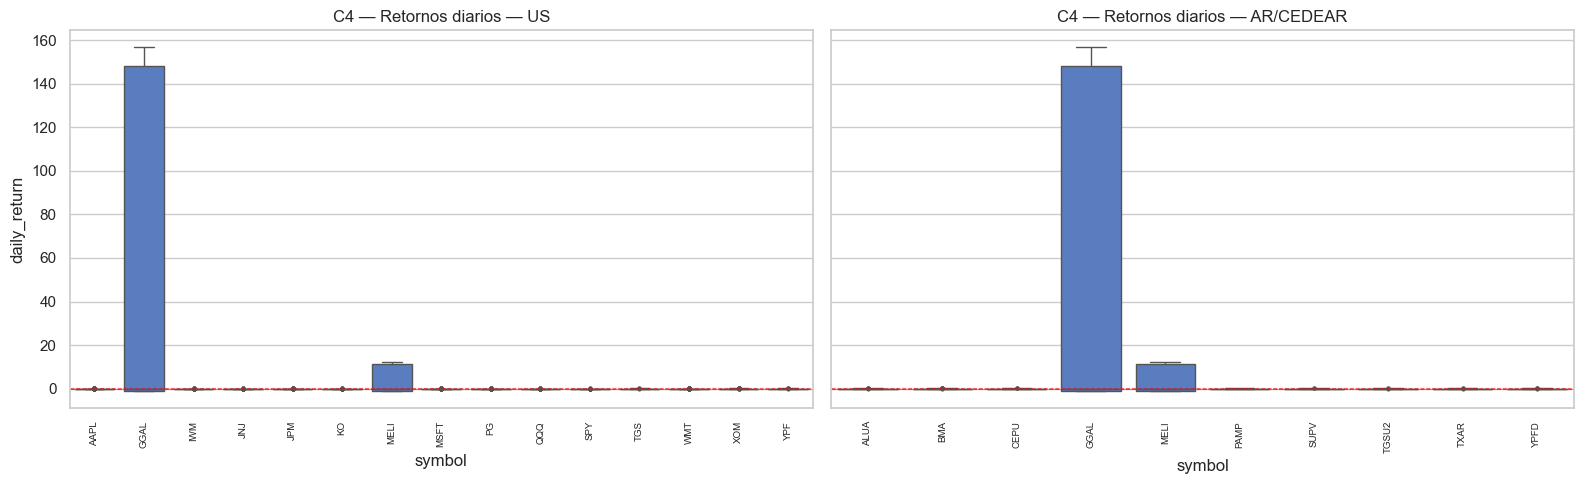

In [24]:
wl_returns = df_sorted[df_sorted["symbol"].isin(DIAGNOSTIC_SYMBOLS)].dropna(subset=["daily_return"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, syms, title in [
    (axes[0], US_SYMBOLS, "US"),
    (axes[1], AR_UNIVERSE_SYMBOLS, "AR/CEDEAR"),
]:
    sub = wl_returns[wl_returns["symbol"].isin(syms)]
    if sub.empty:
        ax.set_title(f"C4 — {title} (sin datos)")
        continue
    sns.boxplot(data=sub, x="symbol", y="daily_return", order=syms, ax=ax, fliersize=2)
    ax.axhline(0, color="gray", ls="-", lw=0.5)
    ax.axhline(RETURN_OUTLIER_THRESHOLD, color="red", ls="--", lw=0.8, alpha=0.6)
    ax.axhline(-RETURN_OUTLIER_THRESHOLD, color="red", ls="--", lw=0.8, alpha=0.6)
    ax.set_title(f"C4 — Retornos diarios — {title}")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

---
## A — Actividad del Motor Corto
### A1. Fills, bloqueos y exits por ventana OOS

In [25]:
# Cargar pre-gate JSON
if not PRE_GATE_JSON.exists():
    raise FileNotFoundError(
        f"No existe {PRE_GATE_JSON}. Ejecutá: "
        "python scripts/run_short_term_pre_gate.py --output outputs/pre_gate_windows_180d_rsi.json"
    )

with open(PRE_GATE_JSON, encoding="utf-8") as f:
    pg = json.load(f)

df_windows = pd.DataFrame(pg["windows"])
df_windows["start_date"] = pd.to_datetime(df_windows["start_date"])
df_windows["end_date"] = pd.to_datetime(df_windows["end_date"])
df_windows["label"] = (
    df_windows["start_date"].dt.strftime("%m-%d")
    + " → "
    + df_windows["end_date"].dt.strftime("%m-%d")
)

print(f"Pre-gate passed: {pg['pre_gate_passed']}")
print(f"Ventanas: {pg['windows_total']} (pass: {pg['windows_passed']}, fail: {pg['windows_failed']})")
df_windows[
    ["window_index", "label", "n_fills", "return_pct", "max_drawdown_pct", "turnover_annualized", "passed"]
].to_string(index=False)

Pre-gate passed: False
Ventanas: 13 (pass: 4, fail: 9)


' window_index         label  n_fills  return_pct  max_drawdown_pct  turnover_annualized  passed\n            0 10-27 → 11-11        1   -0.006682         -0.050947             0.429324   False\n            1 11-10 → 11-25        0    0.000000          0.000000             0.000000    True\n            2 11-24 → 12-10        7   -0.040492         -0.097417             2.369033    True\n            3 12-09 → 12-24        2   -0.007663         -0.129837             0.958845   False\n            4 12-23 → 01-09        5    0.284300         -0.098036             2.283994   False\n            5 01-08 → 01-26        2    0.276473         -0.029459             0.972743    True\n            6 01-23 → 02-09        4    0.219812         -0.050881             1.316026   False\n            7 02-06 → 02-24        2   -0.024967         -0.103853             0.934121   False\n            8 02-23 → 03-10        3   -0.100661         -0.172838             1.478216   False\n            9 03-09 → 03-24  

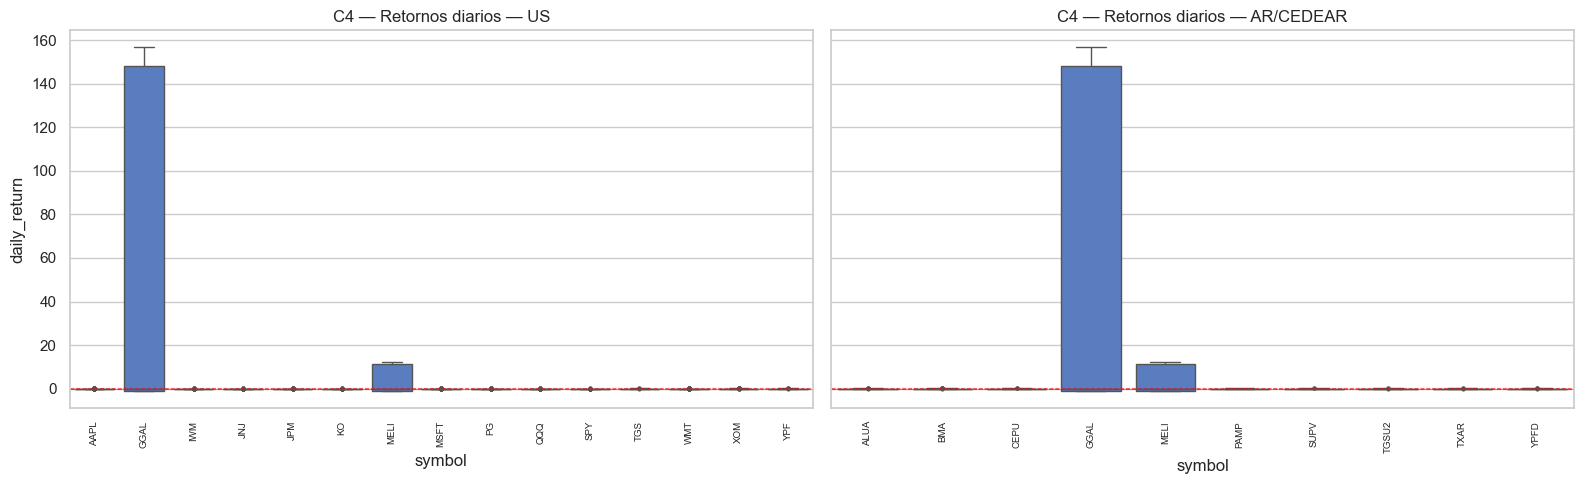

In [26]:
wl_returns = df_sorted[df_sorted["symbol"].isin(DIAGNOSTIC_SYMBOLS)].dropna(subset=["daily_return"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, syms, title in [
    (axes[0], US_SYMBOLS, "US"),
    (axes[1], AR_UNIVERSE_SYMBOLS, "AR/CEDEAR"),
]:
    sub = wl_returns[wl_returns["symbol"].isin(syms)]
    if sub.empty:
        ax.set_title(f"C4 — {title} (sin datos)")
        continue
    sns.boxplot(data=sub, x="symbol", y="daily_return", order=syms, ax=ax, fliersize=2)
    ax.axhline(0, color="gray", ls="-", lw=0.5)
    ax.axhline(RETURN_OUTLIER_THRESHOLD, color="red", ls="--", lw=0.8, alpha=0.6)
    ax.axhline(-RETURN_OUTLIER_THRESHOLD, color="red", ls="--", lw=0.8, alpha=0.6)
    ax.set_title(f"C4 — Retornos diarios — {title}")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

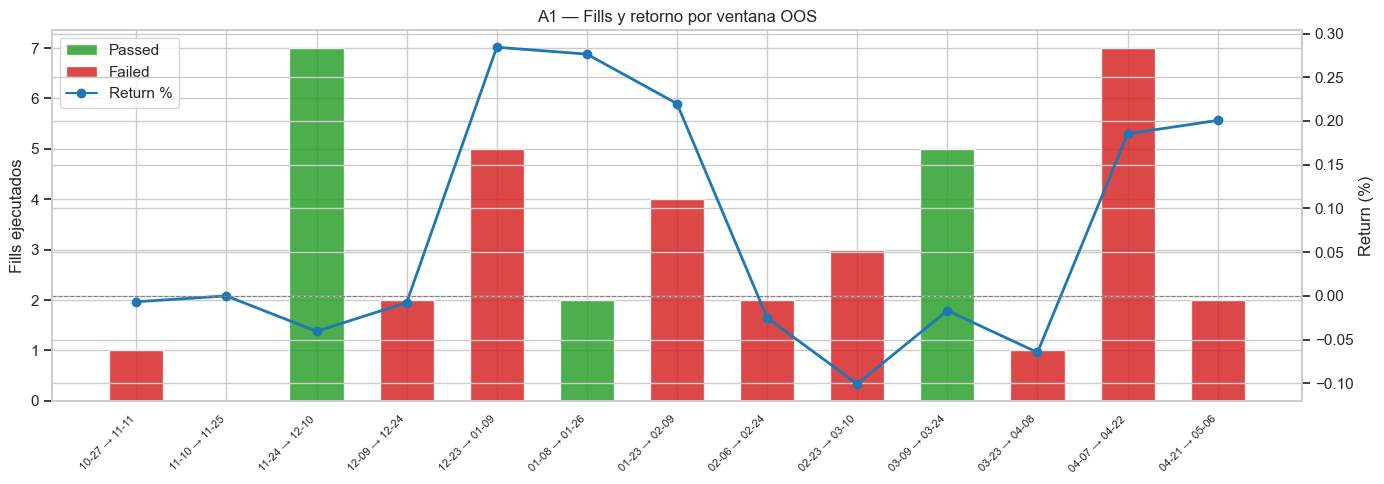

Total fills: 41 | Ventanas sin fills: 1/13 | Return promedio: 0.07%


In [27]:
# A1 — Fills y retorno por ventana OOS
fig, ax1 = plt.subplots(figsize=(14, 5))
x = np.arange(len(df_windows))
bar_w = 0.6

bar_colors = ["#2ca02c" if p else "#d62728" for p in df_windows["passed"]]
ax1.bar(x, df_windows["n_fills"], bar_w, color=bar_colors, alpha=0.85)
ax1.set_ylabel("Fills ejecutados")
ax1.set_xticks(x)
ax1.set_xticklabels(df_windows["label"], rotation=45, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, df_windows["return_pct"], "o-", color="#1f77b4", linewidth=2, markersize=6, label="Return %")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Return (%)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ca02c", alpha=0.85, label="Passed"),
    Patch(facecolor="#d62728", alpha=0.85, label="Failed"),
    plt.Line2D([0], [0], color="#1f77b4", marker="o", label="Return %"),
]
ax1.legend(handles=legend_elements, loc="upper left")
ax1.set_title("A1 — Fills y retorno por ventana OOS")
plt.tight_layout()
plt.show()

total_fills = int(df_windows["n_fills"].sum())
zero_fill_windows = int((df_windows["n_fills"] == 0).sum())
avg_return = df_windows["return_pct"].mean()
print(f"Total fills: {total_fills} | Ventanas sin fills: {zero_fill_windows}/{len(df_windows)} | Return promedio: {avg_return:.2f}%")

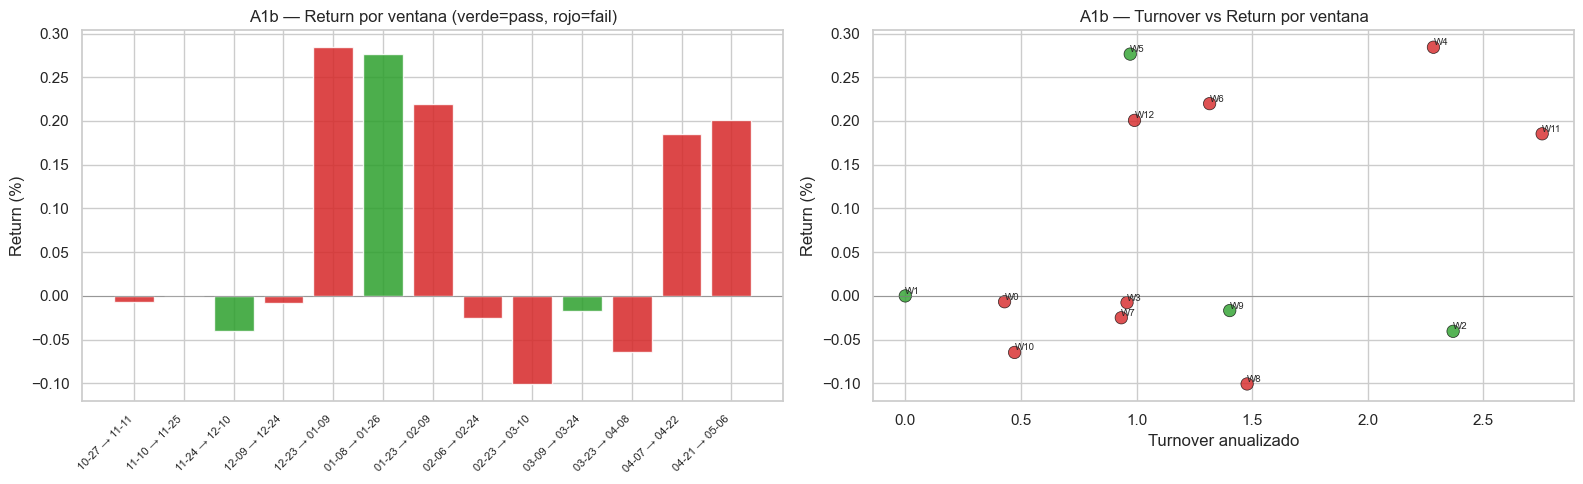

In [28]:
# Return por ventana con color pass/fail
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Return por ventana
ax1 = axes[0]
bar_colors = ["#2ca02c" if p else "#d62728" for p in df_windows["passed"]]
ax1.bar(x, df_windows["return_pct"], color=bar_colors, alpha=0.85)
ax1.axhline(0, color="gray", ls="-", lw=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(df_windows["label"], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Return (%)")
ax1.set_title("A1b — Return por ventana (verde=pass, rojo=fail)")

# Gráfico 2: Scatter turnover vs return
ax2 = axes[1]
scatter_colors = ["#2ca02c" if p else "#d62728" for p in df_windows["passed"]]
ax2.scatter(df_windows["turnover_annualized"], df_windows["return_pct"],
            c=scatter_colors, s=80, alpha=0.8, edgecolors="black", linewidths=0.5)
for _, row in df_windows.iterrows():
    ax2.annotate(f"W{int(row['window_index'])}",
                 (row["turnover_annualized"], row["return_pct"]),
                 fontsize=7, ha="left", va="bottom")
ax2.axhline(0, color="gray", ls="-", lw=0.5)
ax2.set_xlabel("Turnover anualizado")
ax2.set_ylabel("Return (%)")
ax2.set_title("A1b — Turnover vs Return por ventana")

plt.tight_layout()
plt.show()

---
## B — P&L puro (sin reglas de policy)

¿En qué ventanas la estrategia genera dinero y en cuáles pierde?
Acá no importa si la ventana "pasa" o "falla" por drawdown/turnover — solo el resultado neto.

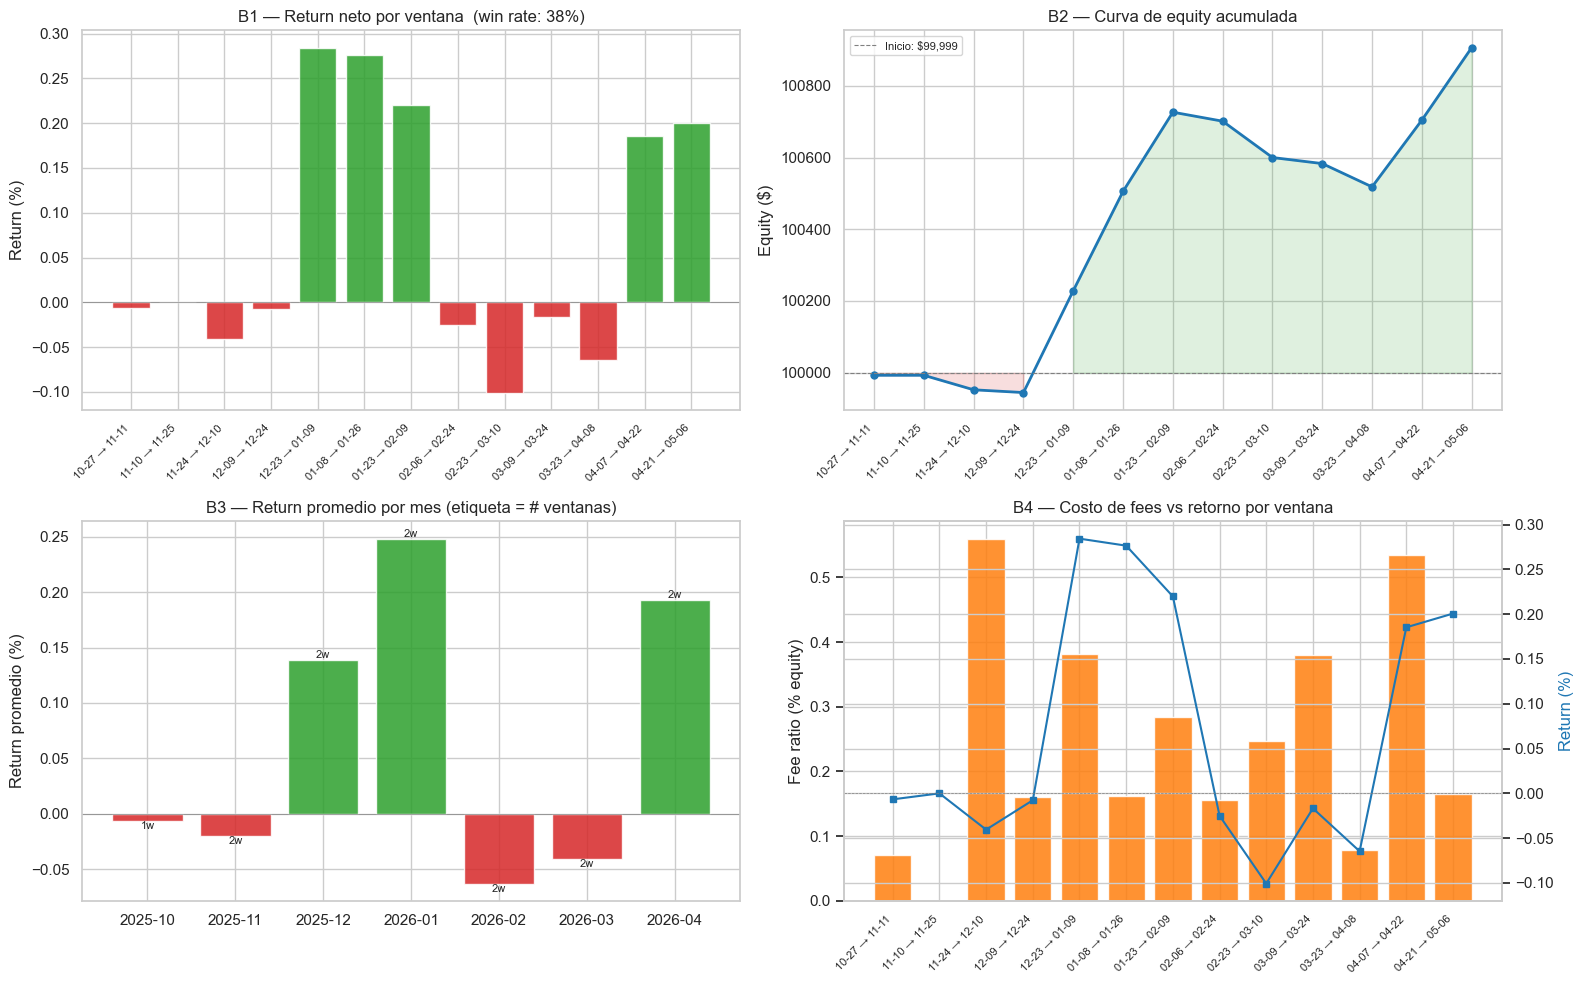

════════════════════════════════════════════════════════════
  P&L SUMMARY  (sin filtros de policy)
════════════════════════════════════════════════════════════
  Ventanas ganadoras : 5/13 (38%)
  Avg win            : +0.233%
  Avg loss           : -0.033%
  Mejor ventana      : W4 (+0.284%)
  Peor ventana       : W8 (-0.101%)
  Return acumulado   : +0.907%
  Fees totales       : $31.78
  Max drawdown (peor): -0.173%
════════════════════════════════════════════════════════════


In [29]:
wins = df_windows["return_pct"] > 0
n_win = wins.sum()
n_loss = (~wins).sum()
win_rate = n_win / len(df_windows) if len(df_windows) > 0 else 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── 1. Return por ventana (verde=ganancia, rojo=pérdida) ──
ax = axes[0, 0]
pnl_colors = ["#2ca02c" if r > 0 else "#d62728" for r in df_windows["return_pct"]]
ax.bar(x, df_windows["return_pct"], color=pnl_colors, alpha=0.85)
ax.axhline(0, color="gray", ls="-", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_windows["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Return (%)")
ax.set_title(f"B1 — Return neto por ventana  (win rate: {win_rate:.0%})")

# ── 2. Equity curve acumulada ──
ax = axes[0, 1]
initial_equity = df_windows["start_equity"].iloc[0]
cumulative_return = (1 + df_windows["return_pct"] / 100).cumprod()
equity_curve = initial_equity * cumulative_return
ax.plot(x, equity_curve, "o-", color="#1f77b4", linewidth=2, markersize=5)
ax.axhline(initial_equity, color="gray", ls="--", lw=0.8, label=f"Inicio: ${initial_equity:,.0f}")
ax.fill_between(x, initial_equity, equity_curve,
                where=equity_curve >= initial_equity, alpha=0.15, color="#2ca02c")
ax.fill_between(x, initial_equity, equity_curve,
                where=equity_curve < initial_equity, alpha=0.15, color="#d62728")
ax.set_xticks(x)
ax.set_xticklabels(df_windows["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Equity ($)")
ax.set_title("B2 — Curva de equity acumulada")
ax.legend(fontsize=8)

# ── 3. P&L mensual ──
ax = axes[1, 0]
df_month = pd.DataFrame(pg["summary_by_month"])
month_colors = ["#2ca02c" if r > 0 else "#d62728" for r in df_month["avg_return_pct"]]
ax.bar(df_month["group"], df_month["avg_return_pct"], color=month_colors, alpha=0.85)
ax.axhline(0, color="gray", ls="-", lw=0.5)
for i, row in df_month.iterrows():
    ax.text(i, row["avg_return_pct"], f"{row['windows']}w",
            ha="center", va="bottom" if row["avg_return_pct"] >= 0 else "top", fontsize=8)
ax.set_ylabel("Return promedio (%)")
ax.set_title("B3 — Return promedio por mes (etiqueta = # ventanas)")

# ── 4. Fees como % del equity inicial ──
ax = axes[1, 1]
ax.bar(x, df_windows["fee_ratio_pct_of_initial"] * 100, color="#ff7f0e", alpha=0.85)
ax2_twin = ax.twinx()
ax2_twin.plot(x, df_windows["return_pct"], "s-", color="#1f77b4", markersize=5, label="Return %")
ax2_twin.axhline(0, color="gray", ls="--", lw=0.5)
ax2_twin.set_ylabel("Return (%)", color="#1f77b4")
ax.set_xticks(x)
ax.set_xticklabels(df_windows["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Fee ratio (% equity)")
ax.set_title("B4 — Costo de fees vs retorno por ventana")

plt.tight_layout()
plt.show()

# ── Resumen numérico ──
avg_win = df_windows.loc[wins, "return_pct"].mean() if n_win > 0 else 0
avg_loss = df_windows.loc[~wins, "return_pct"].mean() if n_loss > 0 else 0
total_return = (cumulative_return.iloc[-1] - 1) * 100
total_fees = df_windows["total_fees"].sum()

print("═" * 60)
print("  P&L SUMMARY  (sin filtros de policy)")
print("═" * 60)
print(f"  Ventanas ganadoras : {n_win}/{len(df_windows)} ({win_rate:.0%})")
print(f"  Avg win            : {avg_win:+.3f}%")
print(f"  Avg loss           : {avg_loss:+.3f}%")
print(f"  Mejor ventana      : W{df_windows.loc[df_windows['return_pct'].idxmax(), 'window_index']:.0f} ({df_windows['return_pct'].max():+.3f}%)")
print(f"  Peor ventana       : W{df_windows.loc[df_windows['return_pct'].idxmin(), 'window_index']:.0f} ({df_windows['return_pct'].min():+.3f}%)")
print(f"  Return acumulado   : {total_return:+.3f}%")
print(f"  Fees totales       : ${total_fees:,.2f}")
print(f"  Max drawdown (peor): {df_windows['max_drawdown_pct'].min():.3f}%")
print("═" * 60)

---
## Diagnóstico automático

Reglas programadas que generan flags. Re-ejecutar el notebook para actualizar.

In [30]:
# ── Reglas de diagnóstico ──────────────────────────────────
flags = []

# --- IOL: fetch_log ---
if df_fetch_log.empty:
    flags.append("⚠ IOL — fetch_log vacío en el lookback (ejecutar fetch_daily)")
elif "df_fl" in dir() and not df_fl.empty:
    iol_ok_rate = df_fl["is_ok"].mean()
    iol_fb_rate = df_fl["is_fallback"].mean()
    if iol_ok_rate < 0.85:
        flags.append(f"⚠ IOL — Tasa de éxito fetch {iol_ok_rate:.1%} (<85%)")
    if iol_fb_rate > 0.25:
        flags.append(f"⚠ IOL — Tasa de fallback {iol_fb_rate:.1%} (>25%) — revisar credenciales IOL o cobertura API")
    top_bad = (
        df_fl[~df_fl["is_ok"]].groupby("symbol").size().sort_values(ascending=False).head(3)
    )
    if not top_bad.empty and top_bad.iloc[0] >= 5:
        flags.append(
            "⚠ IOL — Símbolos con fallos recurrentes: "
            + ", ".join(f"{s}({int(c)})" for s, c in top_bad.items())
        )

# --- C: Calidad de datos ---

def _flag_coverage(label: str, cov: pd.DataFrame, n_exp: int, expected: set) -> None:
    if n_exp == 0:
        flags.append(f"⚠ DATOS — Universo {label} vacío en policy/snapshot")
        return
    if cov.empty:
        flags.append(f"🔴 DATOS — Sin barras {label} en OHLCV")
        return
    days_below = len(cov[cov["n_symbols"] < n_exp * 0.5])
    if days_below > 0:
        flags.append(
            f"⚠ DATOS — {label}: {days_below} día(s) con <50% cobertura (mín {cov['n_symbols'].min()}/{n_exp})"
        )

_flag_coverage("US", coverage_daily_us, len(US_SYMBOLS), expected_sessions_us)
_flag_coverage("AR", coverage_daily_ar, len(AR_UNIVERSE_SYMBOLS), expected_sessions_ar)

for label, pct_series in [("US", coverage_pct_us), ("AR", coverage_pct_ar)]:
    if pct_series is None or (hasattr(pct_series, "empty") and pct_series.empty):
        continue
    bad = pct_series[pct_series < 0.8]
    if not bad.empty:
        flags.append(f"⚠ DATOS — {label} símbolos <80% días: {', '.join(bad.index[:8].tolist())}")

if len(missing_us) > 0:
    pct = len(missing_us) / max(len(expected_sessions_us), 1) * 100
    flags.append(f"⚠ DATOS — {len(missing_us)} sesiones XNYS sin datos US ({pct:.1f}%)")
if len(expected_sessions_us) == 0:
    flags.append("🔴 DATOS — Calendario XNYS vacío")

if len(missing_ar) > 0:
    pct = len(missing_ar) / max(len(expected_sessions_ar), 1) * 100
    flags.append(f"⚠ DATOS — {len(missing_ar)} sesiones XBUE sin datos AR ({pct:.1f}%)")
if len(expected_sessions_ar) == 0:
    flags.append("🔴 DATOS — Calendario XBUE vacío")

critical_integrity = integrity_report.loc[
    ["low_gt_high", "volume_negative", "null_close"],
    "count",
]
if critical_integrity.sum() > 0:
    details = critical_integrity[critical_integrity > 0].to_dict()
    flags.append(f"🔴 DATOS — Integridad OHLCV violada: {details}")

flat_count = int(integrity_report.loc["flat_ohlc", "count"])
if flat_count > len(df_ohlcv) * 0.01:
    flags.append(f"⚠ DATOS — {flat_count} barras flat (O=H=L=C), {flat_count/len(df_ohlcv):.1%} del total")

if len(return_outliers) > 0:
    flags.append(f"⚠ DATOS — {len(return_outliers)} retornos > ±{RETURN_OUTLIER_THRESHOLD:.0%}")

# --- A: Motor corto ---
pass_rate = pg["windows_passed"] / max(pg["windows_total"], 1)
if pass_rate < 0.5:
    flags.append(f"⚠ MOTOR — Solo {pg['windows_passed']}/{pg['windows_total']} ventanas pasan pre-gate ({pass_rate:.0%})")

if zero_fill_windows > len(df_windows) * 0.3:
    flags.append(f"🔴 MOTOR — {zero_fill_windows}/{len(df_windows)} ventanas con 0 fills")

avg_return = df_windows["return_pct"].mean()
if avg_return < 0:
    flags.append(f"⚠ MOTOR — Return promedio negativo: {avg_return:.2f}%")

avg_turnover = df_windows["turnover_annualized"].mean()
negative_return_windows = (df_windows["return_pct"] < 0).sum()
if avg_turnover > 2.0 and negative_return_windows > len(df_windows) * 0.5:
    flags.append(f"⚠ MOTOR — Turnover alto ({avg_turnover:.1f}x) + mayoría ventanas negativas")

print("=" * 70)
print("DIAGNÓSTICO AUTOMÁTICO")
print("=" * 70)
if not flags:
    print("✅ Sin flags. Datos, IOL y motor dentro de parámetros normales.")
else:
    for f in flags:
        print(f)
print("=" * 70)
n_iol = sum(1 for f in flags if "IOL" in f)
n_datos = sum(1 for f in flags if "DATOS" in f)
n_motor = sum(1 for f in flags if "MOTOR" in f)
print(f"\nResumen: {len(flags)} flag(s) | IOL: {n_iol} | Datos: {n_datos} | Motor: {n_motor}")
print(f"  Críticos (🔴): {sum(1 for f in flags if '🔴' in f)} | Advertencias (⚠): {sum(1 for f in flags if '⚠' in f)}")

DIAGNÓSTICO AUTOMÁTICO
⚠ DATOS — 1 sesiones XNYS sin datos US (0.8%)
⚠ DATOS — 2 sesiones XBUE sin datos AR (1.7%)
⚠ DATOS — 460 retornos > ±15%
⚠ MOTOR — Solo 4/13 ventanas pasan pre-gate (31%)

Resumen: 4 flag(s) | IOL: 0 | Datos: 3 | Motor: 1
  Críticos (🔴): 0 | Advertencias (⚠): 4


---
### Siguiente iteración (pendiente)

- Profundizar señales (A2–A4) cuando el JSON del pre-gate exponga fills por trade.
- Alertas automáticas si `fetch_log` supera umbrales de fallback (integración con paper-live).